In [1]:
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

import numpy as np

/Users/demouser/.local/share/virtualenvs/qiskit-playground-xSEsUWdl/lib/python3.14/site-packages/qiskit/visualization/circuit/matplotlib.py:272: UserWarning: Style JSON file 'default.json' not found in any of these locations: /Users/demouser/.local/share/virtualenvs/qiskit-playground-xSEsUWdl/lib/python3.14/site-packages/qiskit/visualization/circuit/styles/default.json, ~/default.json, ~/.qiskit/default.json, default.json. Will use default style.
  self._style, def_font_ratio = load_style(


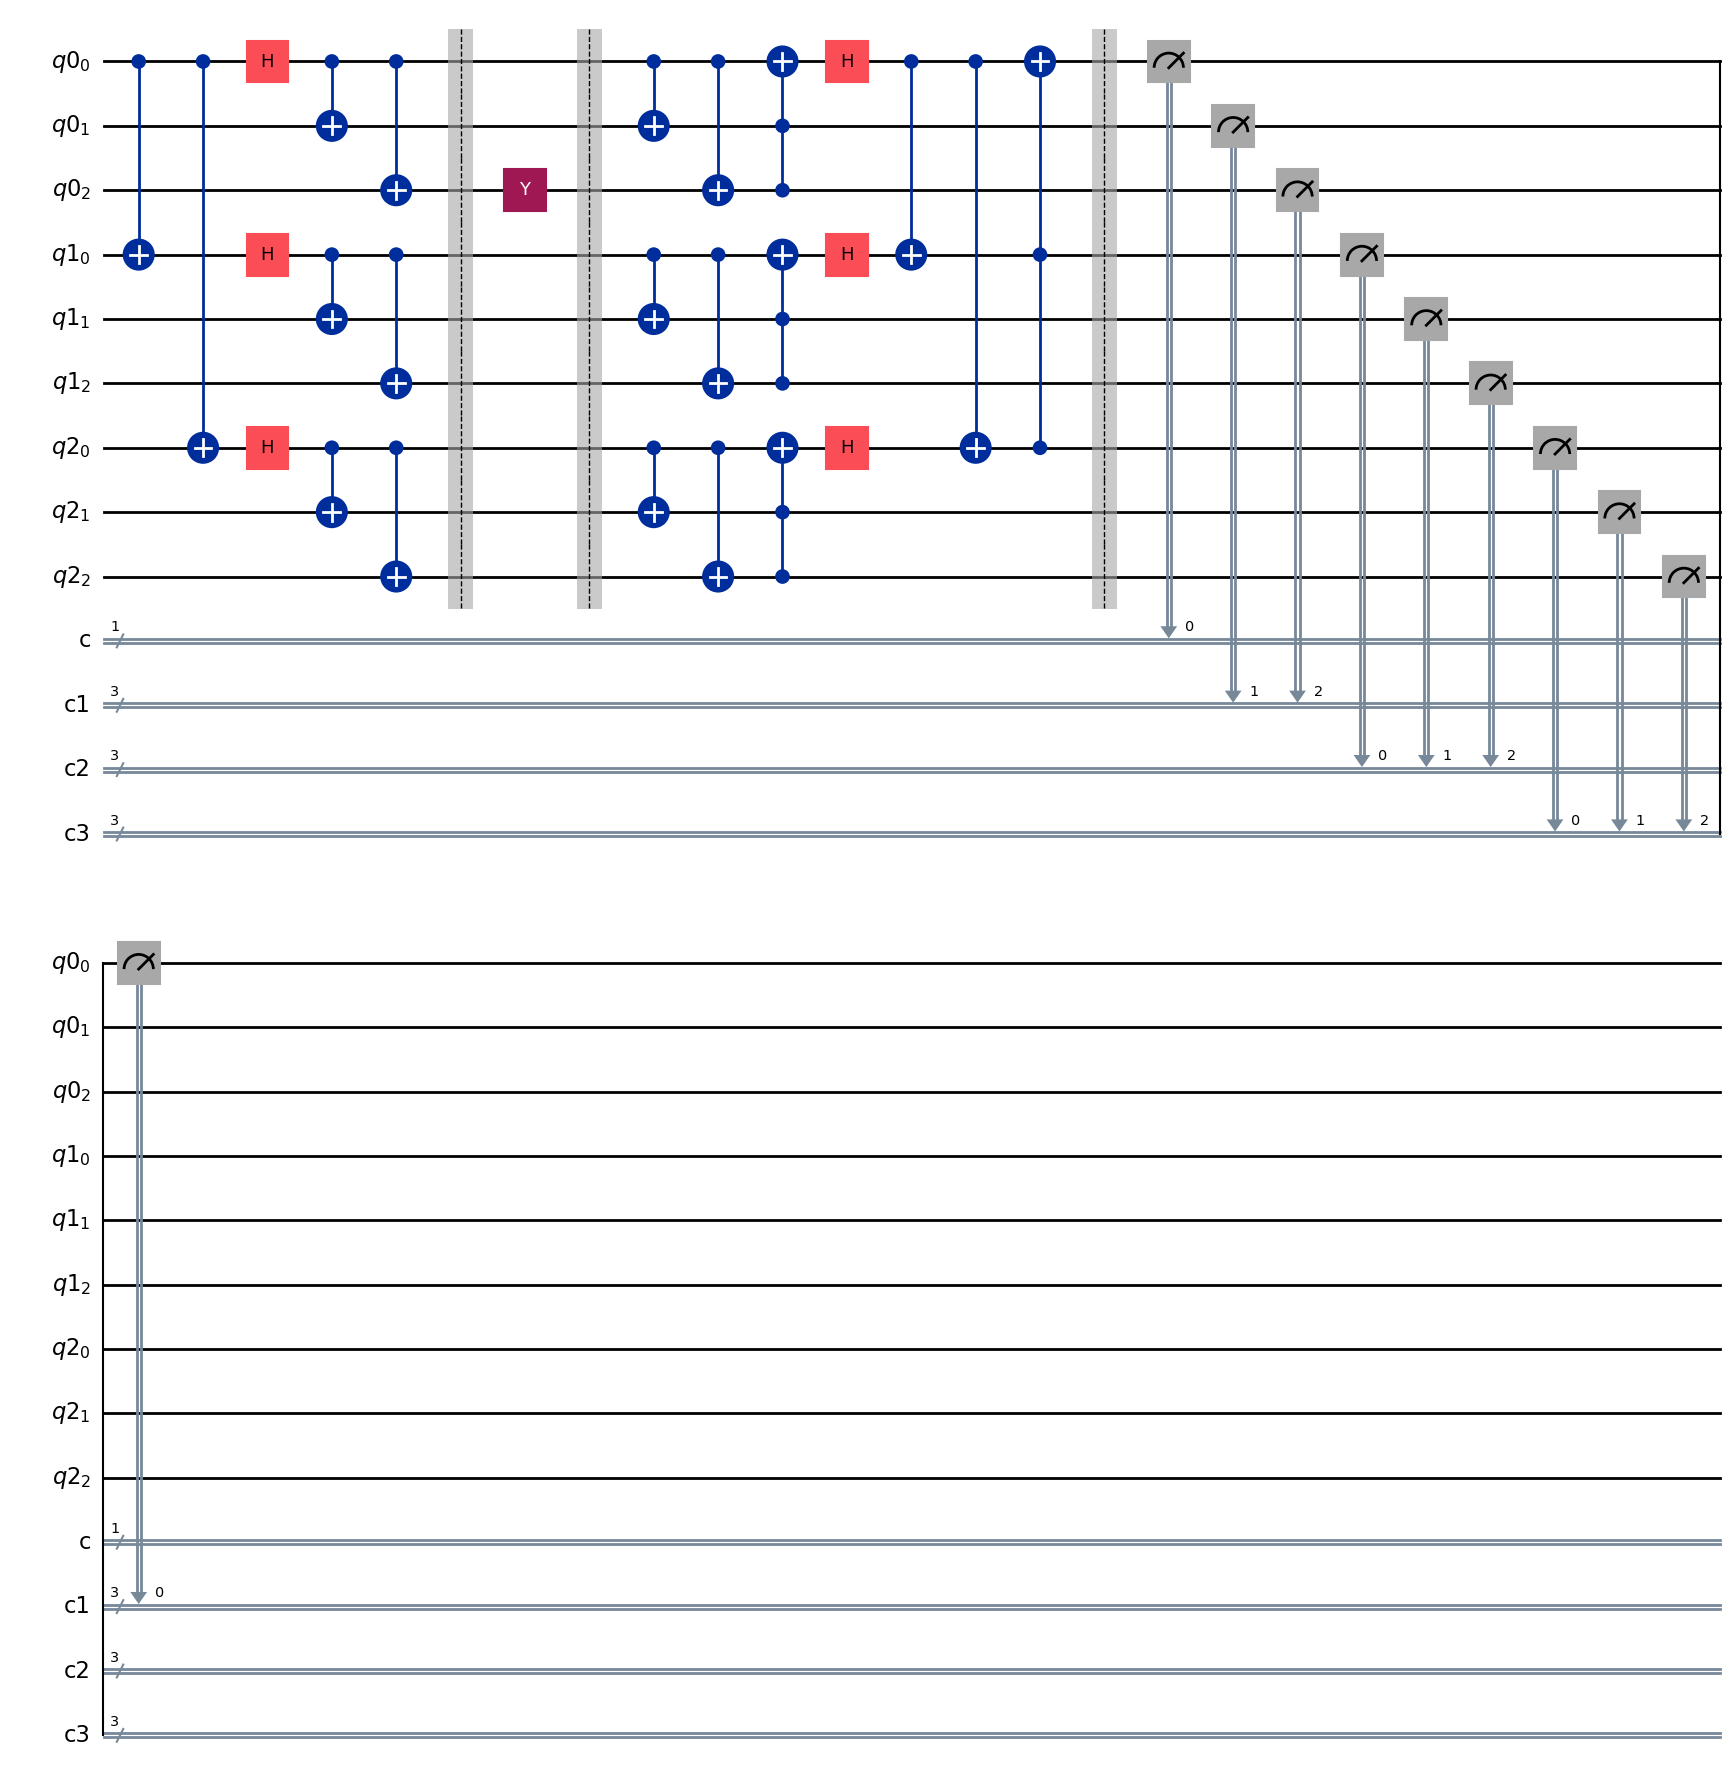

In [38]:
q0 = QuantumRegister(3, "q0")
q1 = QuantumRegister(3, "q1")
q2 = QuantumRegister(3, "q2")
c = ClassicalRegister(1, "c")
c1 = ClassicalRegister(3, "c1")
c2 = ClassicalRegister(3, "c2")
c3 = ClassicalRegister(3, "c3")

qc = QuantumCircuit(q0, q1, q2, c, c1, c2, c3)
qc.cx(q0[0], q1[0])
qc.cx(q0[0], q2[0])

qc.h(q0[0])
qc.h(q1[0])
qc.h(q2[0])

qc.cx(q0[0], q0[1])
qc.cx(q0[0], q0[2])
qc.cx(q1[0], q1[1])
qc.cx(q1[0], q1[2])
qc.cx(q2[0], q2[1])
qc.cx(q2[0], q2[2])
qc.barrier()

qc.y(q0[2])
qc.barrier()

qc.cx(q0[0], q0[1])
qc.cx(q0[0], q0[2])
qc.ccx(q0[2], q0[1], q0[0])

qc.cx(q1[0], q1[1])
qc.cx(q1[0], q1[2])
qc.ccx(q1[2], q1[1], q1[0])

qc.cx(q2[0], q2[1])
qc.cx(q2[0], q2[2])
qc.ccx(q2[2], q2[1], q2[0])

qc.h(q0[0])
qc.h(q1[0])
qc.h(q2[0])

qc.cx(q0[0], q1[0])
qc.cx(q0[0], q2[0])
qc.ccx(q2[0], q1[0], q0[0])
qc.barrier()

qc.measure(q0[0], c)
qc.measure([q0[0], q0[1], q0[2]], c1)
qc.measure([q1[0], q1[1], q1[2]], c2)
qc.measure([q2[0], q2[1], q2[2]], c3)
qc.draw(output='mpl')

In [4]:
service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True, min_num_qubits=10)

In [39]:
pm = generate_preset_pass_manager(backend=backend)
isa_qc = pm.run(qc)
sampler = Sampler(mode=backend)
result = sampler.run([isa_qc]).result()
result

PrimitiveResult([SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=4096, num_bits=1>), c1=BitArray(<shape=(), num_shots=4096, num_bits=3>), c2=BitArray(<shape=(), num_shots=4096, num_bits=3>), c3=BitArray(<shape=(), num_shots=4096, num_bits=3>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': ExecutionSpans([DoubleSliceSpan(<start='2026-03-14 22:14:34', stop='2026-03-14 22:14:36', size=4096>)])}, 'version': 2})

In [40]:
data = result[0].data
data

DataBin(c=BitArray(<shape=(), num_shots=4096, num_bits=1>), c1=BitArray(<shape=(), num_shots=4096, num_bits=3>), c2=BitArray(<shape=(), num_shots=4096, num_bits=3>), c3=BitArray(<shape=(), num_shots=4096, num_bits=3>))

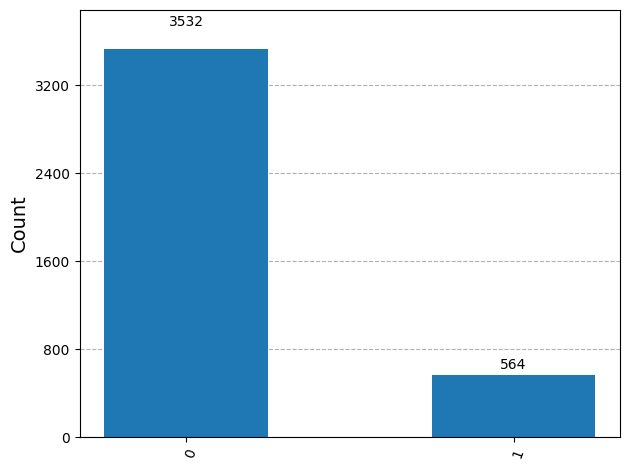

In [41]:
plot_histogram(data['c'].get_counts())

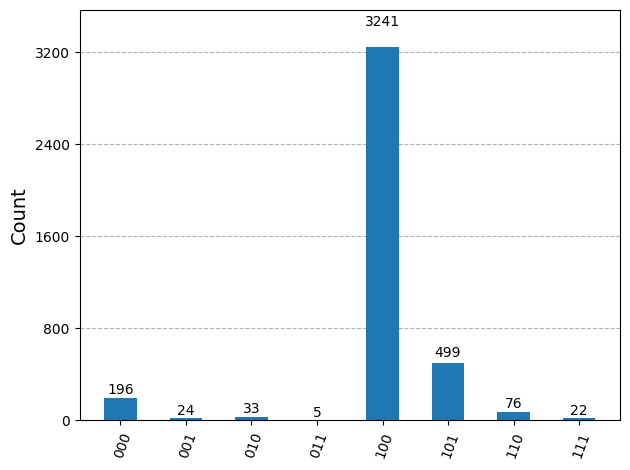

In [42]:
plot_histogram(data['c1'].get_counts())

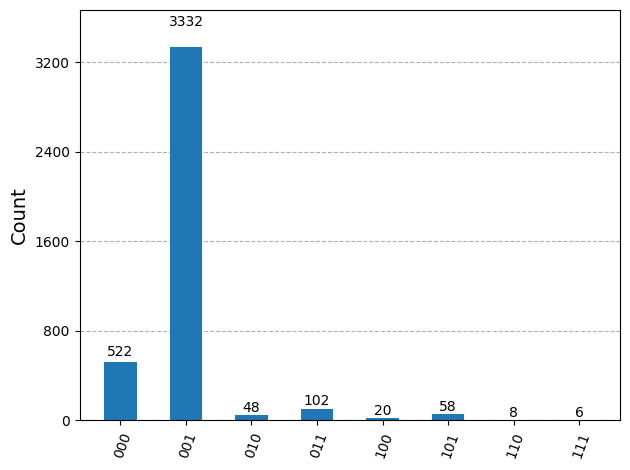

In [43]:
plot_histogram(data['c2'].get_counts())

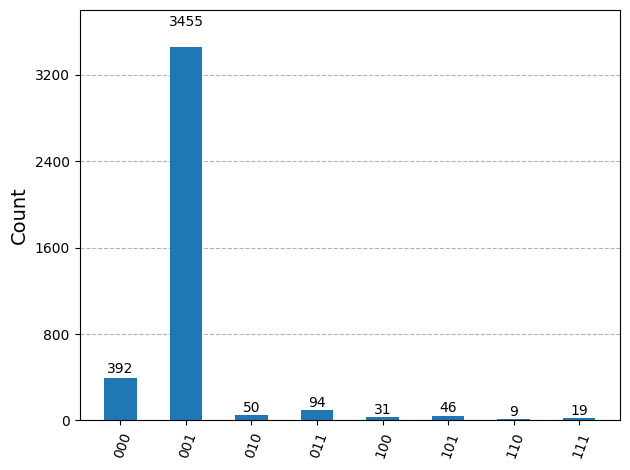

In [44]:
plot_histogram(data['c3'].get_counts())